<a href="https://colab.research.google.com/github/rajesh0305/Image-Processing-And-Computer-Vision-/blob/main/%F0%9F%A7%A0%F0%9F%A7%A0U_Net_Image_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
tanlikesmath_the_oxfordiiit_pet_dataset_path = kagglehub.dataset_download('tanlikesmath/the-oxfordiiit-pet-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'the-oxfordiiit-pet-dataset' dataset.
Data source import complete.


![](https://i.postimg.cc/pXH73C6q/Screenshot-2025-06-07-200654.png)

# Imports and Setup 📦

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

# Load Oxford-IIIT Pet Dataset 🐶

In [3]:
dataset, info = tfds.load('oxford_iiit_pet', with_info=True)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.JQKO3R_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.JQKO3R_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


# Data Preprocessing: Resize, Augment & Normalize 🔄

In [4]:
def resize(input_image, input_mask):
    # Resize input image to 128x128
    resized_image = tf.image.resize(images=input_image, size=(128, 128))

    # Resize segmentation mask to 128x128
    resized_mask = tf.image.resize(images=input_mask, size=(128, 128))

    return resized_image, resized_mask


In [5]:
def augment(input_image, input_mask):
   if tf.random.uniform(()) > 0.5:
       input_image = tf.image.flip_left_right(input_image)
       input_mask = tf.image.flip_left_right(input_mask)
   return input_image, input_mask

In [6]:
def normalize(input_image, input_mask):
    return tf.cast(input_image, tf.float32) / 255.0, input_mask - 1

In [7]:
def load_image(datapoint, augment_data=False):
    input_image = datapoint["image"]
    input_mask = datapoint["segmentation_mask"]

    input_image, input_mask = resize(input_image, input_mask)

    if augment_data:
        input_image, input_mask = augment(input_image, input_mask)

    input_image, input_mask = normalize(input_image, input_mask)

    return input_image, input_mask


# Prepare Datasets 🔄

In [8]:
train_dataset = dataset["train"].map(
    lambda x: load_image(x, augment_data=True),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = dataset["test"].map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)


# Data Batching & Prefetching 📦

In [9]:
BATCH_SIZE = 64
BUFFER_SIZE = 1000

# Prepare the training dataset:
# 1. Cache the data in memory for faster access
# 2. Shuffle the data with a buffer
# 3. Batch the data
# 4. Repeat the dataset forever (for training)
# 5. Prefetch to improve performance
train_batches = train_dataset.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()
train_batches = train_batches.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

# Prepare the validation dataset (first 3000 samples from test set)
validation_batches = test_dataset.take(3000).batch(BATCH_SIZE)
# Prepare the test dataset (next 669 samples after validation split)
test_batches = test_dataset.skip(3000).take(669).batch(BATCH_SIZE)

# Display Sample Image & Mask 🖼️

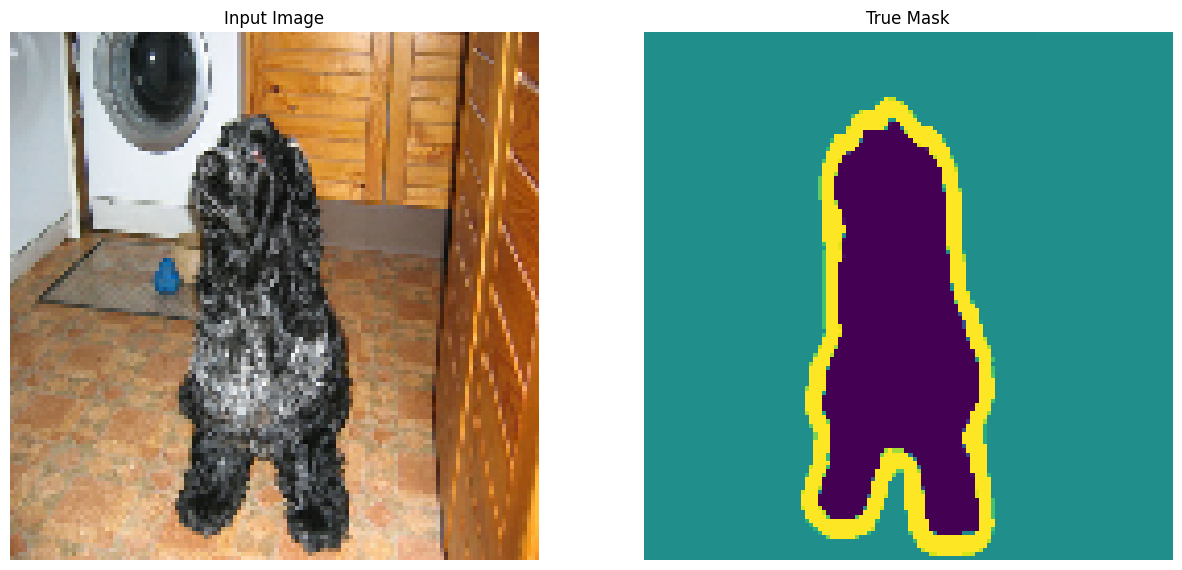

In [10]:
# Function to display input image, true mask, and predicted mask (if provided)
def display(display_list):

    plt.figure(figsize=(15, 15))
    titles = ["Input Image", "True Mask", "Predicted Mask"]

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i + 1)
        plt.title(titles[i])
        plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
        plt.axis("off")

    plt.show()

# Get one batch from the training dataset
sample_batch = next(iter(train_batches))

# Randomly choose an index from the batch (0 to 63 , if batch_size = 64)
random_index = np.random.choice(sample_batch[0].shape[0])

# Extract the image and corresponding mask using the random index
sample_image = sample_batch[0][random_index]
sample_mask = sample_batch[1][random_index]

# Display the image and its true mask
display([sample_image, sample_mask])


# U-Net Blocks 🔧

In [11]:
def double_conv_block(x, n_filters):
   x = layers.Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)
   x = layers.Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)
   return x

In [12]:
def downsample_block(x, n_filters):
   f = double_conv_block(x, n_filters)
   p = layers.MaxPool2D(2)(f)
   p = layers.Dropout(0.3)(p)
   return f, p

In [13]:
def upsample_block(x, conv_features, n_filters):
   x = layers.Conv2DTranspose(n_filters, 3, 2, padding="same")(x)
   x = layers.concatenate([x, conv_features])
   x = layers.Dropout(0.3)(x)
   x = double_conv_block(x, n_filters)
   return x

# Main U-Net Model Architecture 🏗️

In [14]:

def build_unet_model():
    # Input layer
    inputs = layers.Input(shape=(128, 128, 3))

    # Encoder (Downsampling path)
    f1, p1 = downsample_block(inputs, 64)    # First downsampling
    f2, p2 = downsample_block(p1, 128)       # Second downsampling
    f3, p3 = downsample_block(p2, 256)       # Third downsampling
    f4, p4 = downsample_block(p3, 512)       # Fourth downsampling

    # Bottleneck (Bottom of the "U")
    bottleneck = double_conv_block(p4, 1024)

    # Decoder (Upsampling path with skip connections)
    u6 = upsample_block(bottleneck, f4, 512) # First upsampling
    u7 = upsample_block(u6, f3, 256)         # Second upsampling
    u8 = upsample_block(u7, f2, 128)         # Third upsampling
    u9 = upsample_block(u8, f1, 64)          # Fourth upsampling

    # Output layer
    outputs = layers.Conv2D(
        filters=3,                # 3 classes (background, pet, outline)
        kernel_size=1,            # 1x1 convolution
        padding="same",
        activation="softmax"      # Softmax for multi-class segmentation
    )(u9)

    # Define the model
    unet_model = tf.keras.Model(inputs=inputs, outputs=outputs, name="U-Net")

    return unet_model


In [15]:
unet_model = build_unet_model()


In [16]:
unet_model.compile(optimizer=tf.keras.optimizers.Adam(),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

# Training the Model 🚀

In [17]:
# Set the number of epochs
NUM_EPOCHS = 10

# Calculate dataset lengths
TRAIN_LENGTH = info.splits["train"].num_examples
TEST_LENGTH = info.splits["test"].num_examples

# Define steps per epoch for training and validation
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE
VAL_SUBSPLITS = 5
VALIDATION_STEPS = TEST_LENGTH // BATCH_SIZE // VAL_SUBSPLITS

# Early stopping callback: stops training if validation doesn't improve for 3 epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)

# Train the model
model_history = unet_model.fit(
    train_batches,
    epochs=NUM_EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=test_batches,
    validation_steps=VALIDATION_STEPS,
    callbacks=[early_stopping]
)


Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.5721 - loss: 0.9362 - val_accuracy: 0.5826 - val_loss: 0.8554
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.6224 - loss: 0.7866 - val_accuracy: 0.6833 - val_loss: 0.7151
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.7203 - loss: 0.6513 - val_accuracy: 0.7535 - val_loss: 0.6018
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.7445 - loss: 0.6118 - val_accuracy: 0.7463 - val_loss: 0.5987
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.7662 - loss: 0.5625 - val_accuracy: 0.7780 - val_loss: 0.5395
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.7799 - loss: 0.5302 - val_accuracy: 0.8004 - val_loss: 0.4868
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.7933 - loss: 0.5007 - val_accuracy: 0.7840 - val_loss: 0.5247
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8018 - loss: 0.4803 - val_accuracy: 0.8113 - val_los

# Display Predictions 🖼️

In [18]:
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1) # (batch_size, height, width, num_classes)
    pred_mask = pred_mask[..., tf.newaxis]
    # Take all dimensions as-is, and then add a new one at the end.
    return pred_mask[0]

def show_predictions(dataset, num=1):
    for image, mask in dataset.take(num):
        pred_mask = unet_model.predict(image)
        display([image[0], mask[0], create_mask(pred_mask)])


2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 210ms/step


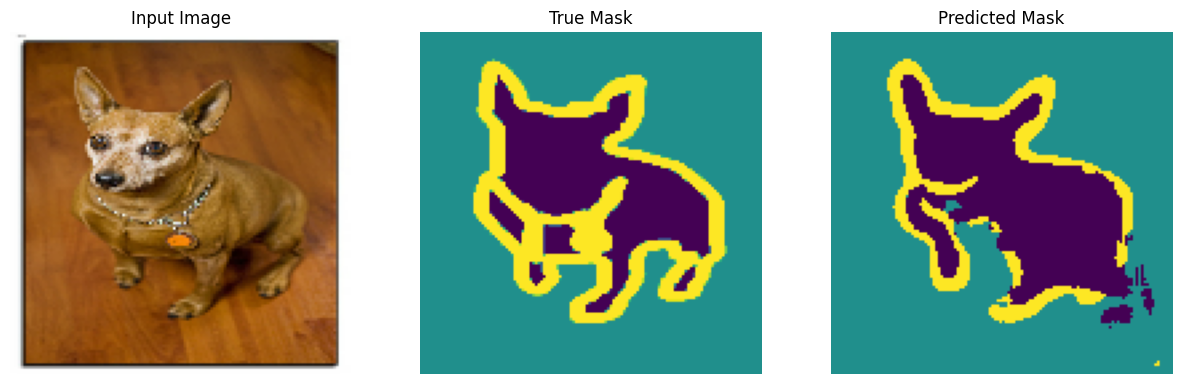

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


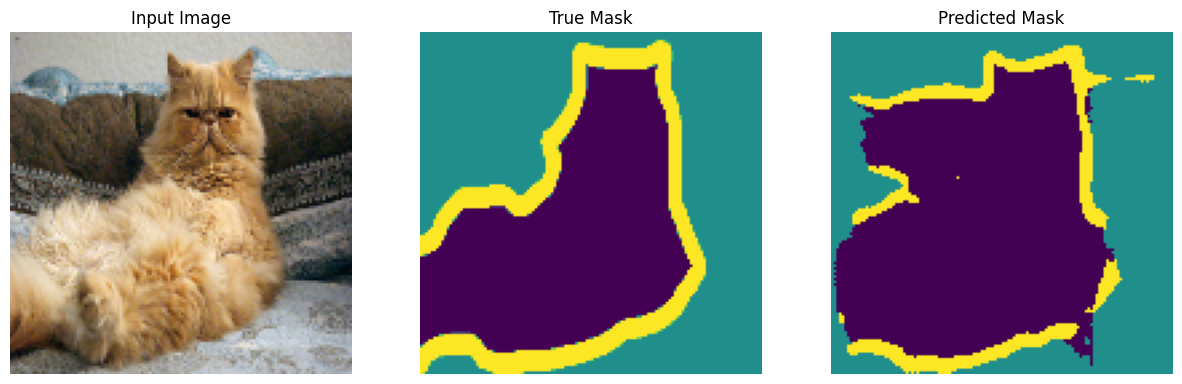

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


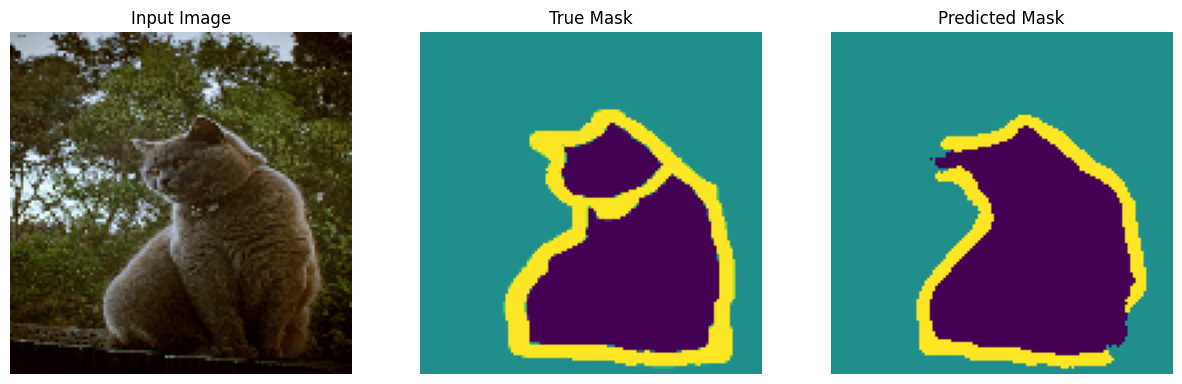

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


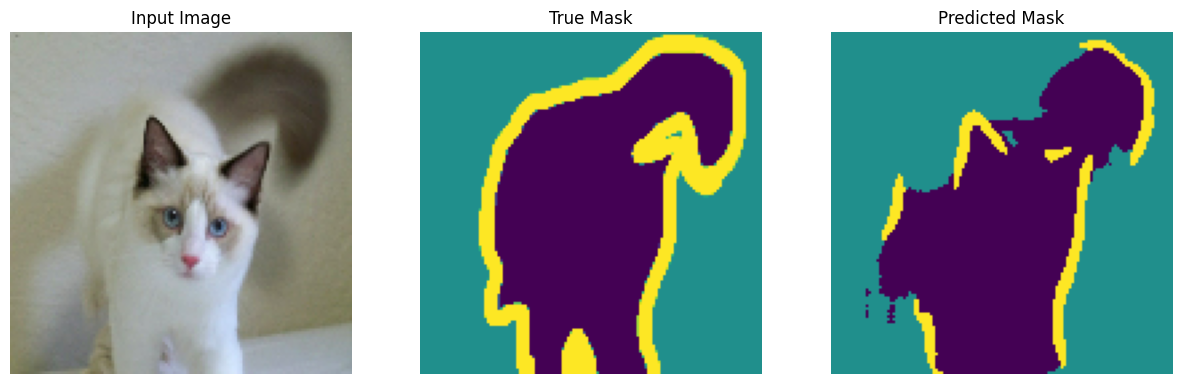

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


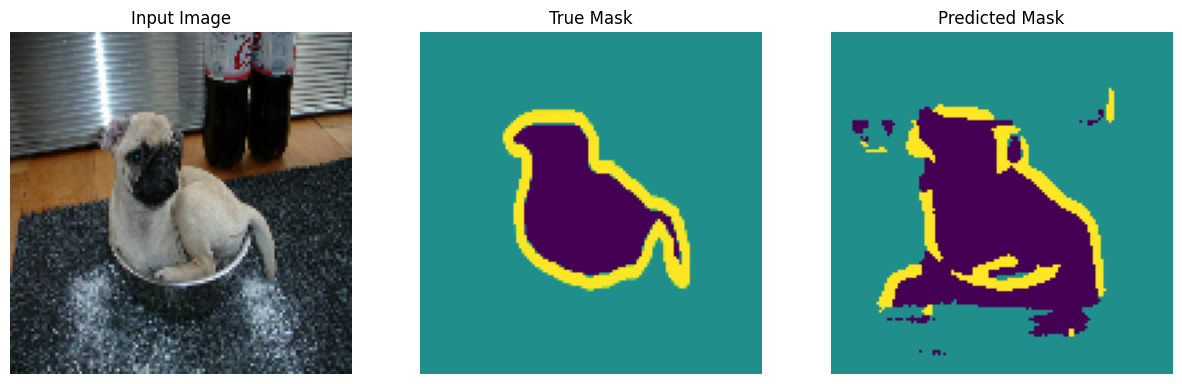

In [19]:
show_predictions(test_batches, 5)


# Save the trained model as HDF5 file 💾

In [21]:
unet_model.save('unet_model.h5')  # Save as HDF5 file

<span style="color: white; background-color: red; padding: 10px 20px; border-radius: 10px; font-size: 36px; font-weight: bold;">Thank you ❤️ 🚀😃</span>